Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530

Data shape dat: (530, 530)
data dtype: >i2
mode: ModeResult(mode=np.int16(3551), count=np.int64(876))


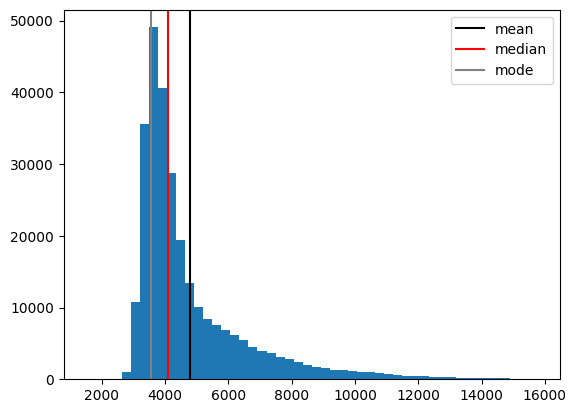

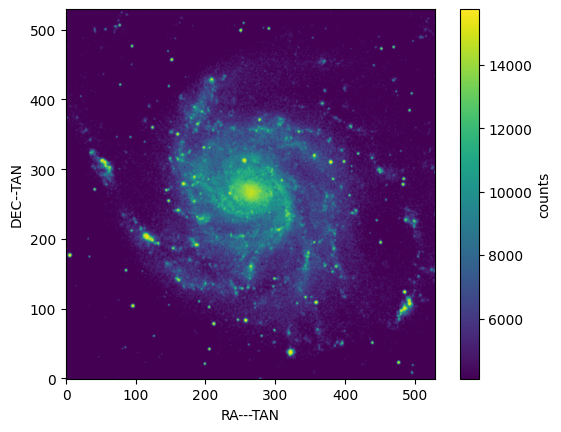

 [astropy.io.fits.verify]


In [55]:
# 6.1
import numpy as np
from astropy.io import fits
from matplotlib.pyplot import figure, show
from scipy import stats
hdulist = fits.open('m101.fits')
hdulist.info()
#2 HDU's, HDU with index 0 contains the image data, the number type is int16

hdr = hdulist[0].header
for key in hdr[:5]:
    print(f'{key:18s}= {hdr[key]}')  # BITPIX = 16, which corresponds to int16

dat1 = hdulist[0].data
print(f'\nData shape dat: {dat1.shape}') # shape is (530, 530)
print(f'data dtype: {dat1.dtype}')

dat = dat1.flat
dmin, dmax, mean, std, median = np.min(dat), np.max(dat), np.mean(dat), np.std(dat), np.median(dat)
mode = stats.mode(dat)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.hist(dat, bins=50)
frame.axvline(mean, color='black', label='mean')
frame.axvline(median, color='red', label='median')
print(f'mode: {mode}')
frame.axvline(3551, color='grey', label='mode')
frame.legend()
show()

new_dat = np.asarray(dat1, dtype=float)
fig = figure()
frame = fig.add_subplot(1,1,1)
s = frame.imshow(new_dat, origin='lower', vmin=median)
frame.set_xlabel(hdr['CTYPE1'])
frame.set_ylabel(hdr['CTYPE2'])
fig.colorbar(s, ax=frame, label='counts')
show()

hdr['BUNIT'] = 'Counts'

hdulistout = fits.PrimaryHDU(new_dat)
hdulistout.header = hdr    # copy the old header
hdulistout.writeto('floating.fits', overwrite=True, output_verify='ignore') # ignore invalid header keywords


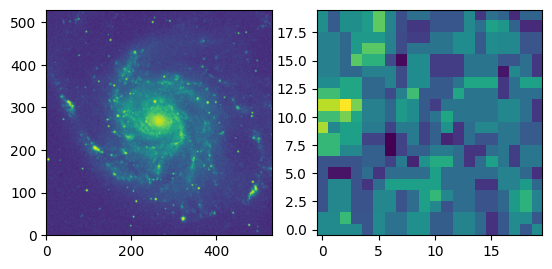

The RMS in the selected area is: 3432.752866505248
mean: 3422.8825 and std: 260.1300322795313


In [56]:
# 6.3
import numpy as np
from astropy.io import fits
from matplotlib.pyplot import figure, show
hdulist = fits.open('m101.fits')

dat = np.asarray(hdulist[0].data, dtype=float)
fig = figure()
frame = fig.add_subplot(1, 2, 1)
frame.imshow(dat, origin='lower')
frame2 = fig.add_subplot(1, 2, 2)
sliced_dat = dat[:20, :20]
frame2.imshow(sliced_dat, origin='lower')
show()

flat_data = sliced_dat.flatten()
rms = np.sqrt((np.mean(flat_data**2)))
print(f'The RMS in the selected area is: {rms}')
print(f'mean: {np.mean(flat_data)} and std: {np.std(flat_data)}')
# Std is a different formula then RMS, only if the mean is 0, they would be the same value
# The std should be used

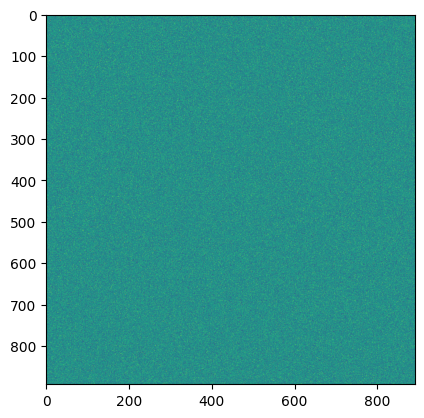

numpy std: 5.773191380233297
std with formula: 5.770294583366141


In [7]:
# 6.5
import numpy as np
from astropy.io import fits
from matplotlib.pyplot import figure, show

dat, std = [], []
for i in range(3):
    hdulist = fits.open(f'noisemap{i}.fits')
    dat1 = hdulist[0].data
    std1 = np.std(dat1)
    dat.append(dat1)
    std.append(std1)

stacking = np.stack(dat, axis=0) # z direction
mean_image = np.mean(stacking, axis=0)

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.imshow(mean_image)
show()

print(f'numpy std: {np.std(mean_image)}')
sigma = (np.sqrt(std[0]**2+std[1]**2+std[2]**2))/len(std)
print(f'std with formula: {sigma}')

In [3]:
# 6.6
from astropy.io import fits
from astropy.table import QTable
import astropy.units as u
import numpy as np

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

DATAFLAG = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    ((data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR']) > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)
t = QTable(data, names=colnames)
t['DATAFLAG'] = DATAFLAG
abs_mag = data['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5 * np.log10(data['GAIAEDR3_PARALLAX']/1000) + 5
abs_mag = np.where(DATAFLAG, abs_mag, -1) 
t['ABSOLUTE_MAGNITUDE'] = abs_mag
print(t)

t.write('APOGEE_updates.fits')

GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG ABSOLUTE_MAGNITUDE
----------------- ----------------------- ... -------- ------------------
              nan                     nan ...    False               -1.0
       0.28544167                0.019475 ...    False               -1.0
       0.08209286                0.315081 ...    False               -1.0
        1.2985312              0.00952245 ...    False               -1.0
        1.2985312              0.00952245 ...     True          2.7881622
      -0.02394128               0.0450072 ...    False               -1.0
        1.3863556               0.0175672 ...     True          2.9852724
              ...                     ... ...      ...                ...
         4.132398                0.015343 ...    False               -1.0
      0.057267956               0.0597211 ...    False               -1.0
        1.4367273               0.0213831 ...    False               -1.0
       0.42296618               0.0192

/tmp/ipykernel_1275065/4161260755.py:25: RuntimeWarning: invalid value encountered in log10
  abs_mag = data['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5 * np.log10(data['GAIAEDR3_PARALLAX']/1000) + 5


OSError: File APOGEE_updates.fits already exists. If you mean to replace it then use the argument "overwrite=True".

RangeIndex(start=64, stop=65, step=1)
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


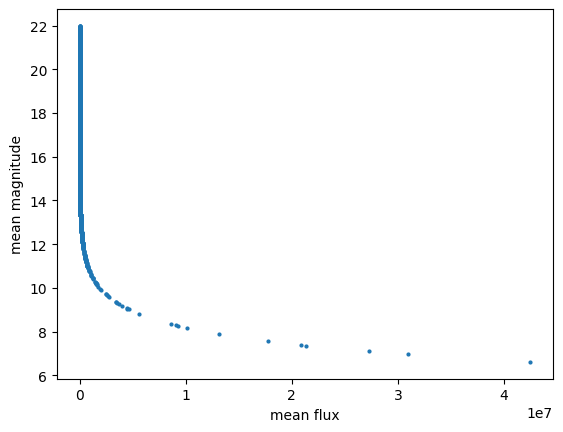

Found value for m_0: 25.68840037029544


In [49]:
# 6.7
import pandas as pd
import numpy as np
from matplotlib.pyplot import figure, show

df = pd.read_csv('gaiaTestData.csv')
max_val = df['phot_g_mean_flux'].max()
print(df[df['phot_g_mean_flux']==max_val].index) # get index of max value
print(df[64:65]) # print corresponding row with the max value

df = df.sort_values(by='phot_g_mean_flux', ascending=True)

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.scatter(df['phot_g_mean_flux'], df['phot_g_mean_mag'], marker='o', s=4)
frame.set_xlabel('mean flux')
frame.set_ylabel('mean magnitude')
show()

# find F_g,0
F_g = df['phot_g_mean_flux']
m_g = df['phot_g_mean_mag']
F_g0 = F_g / 10**(m_g/-2.5)

# calculate m_0
m_0 = 2.5 * np.log10(F_g0)
m_0_mean = np.mean(m_0)
print(f'Found value for m_0: {m_0_mean}')

In [2]:
# 6.10
from astroquery.gaia import Gaia
from astropy.table import QTable
import numpy as np
import pandas as pd

random_query = """
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error,
    phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/ parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""

job = Gaia.launch_job(random_query)
results = job.get_results()
df = results.to_pandas()

t = QTable.from_pandas(df)
t.write('astroquery_gaia.fits', overwrite=True)

In [6]:
#6.14
class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    def __init__(self):
        self.fibo = [0, 1]
	
    def nterm(self, N):
        '''Calculates N-th term in the Fibonacci sequence'''
        self.fibo = [0, 1]
        for i in range(N):
            self.fibo.append(self.fibo[i]+self.fibo[i+1])
        return self.fibo[N-1]
    
    def dividable(self, N, M):
        '''Calculates fibo sequence less than the N-th term and dividable by M'''
        nth_term = self.nterm(N)
        new_fibo = [x for x in self.fibo if x%M==0 and x<nth_term]
        return new_fibo
    
fibo1 = Fibonacci()
example = fibo1.dividable(100, 7)
print(example)
print(fibo1.nterm(2))

[0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
1
